In [6]:
import sys
import os
sys.path.append(os.path.abspath('../..'))


# from scan_engine.status_fields_config_24summ import STATUS_FIELDS_CONFIG
from status_fields_config_oct3v1_brws_250525 import STATUS_FIELDS_CONFIG

from utlis.scan_engine_utlis.scan_eng_big_utlis import log_folder_to_parquet_sep

if __name__ == "__main__":
    base_folder = "/data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog"
    # "/data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/"
    # base_folder = "/data/big_rim/rsync_dcc_sum/25juneon" #"/data/big_rim/rsync_dcc_sum/24summ" #"/data/big_rim/rsync_dcc_sum/25Apri_social" #"/data/big_rim/rsync_dcc_sum/Oct3V1" #"/hpc/group/tdunn/Bryan_Rigs/BigOpenField/24summ"  # Replace with your base folder
    # save_path = os.path.join(base_folder, 'paret')
    failed_paths_file = None #'/data/big_rim/rsync_dcc_sum/Oct3V1/sync_failed_brws.txt'  # File containing failed paths


    force_rescan_rec_files = [
        # ('2023-10-01', '001'),
        # ('2023-10-02', '002'),
        # Add more as needed
    ]
    rescan_threshold_days = 0.000001 # 7 days, but guess if i mess up i can just change it to automatically rescan all, smile... #0.1

    log_folder_to_parquet_sep(base_folder, failed_paths_file, STATUS_FIELDS_CONFIG,
                              force_rescan_rec_files=force_rescan_rec_files,
                              rescan_threshold_days=rescan_threshold_days)


Log for 01mouse_base01 saved at /data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_13/01mouse_base01/folder_log.parquet
Log for 02mouse_base01 saved at /data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_13/02mouse_base01/folder_log.parquet
Log for 02mouse_base02 saved at /data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_14/02mouse_base02/folder_log.parquet
Log for 02mouse_newobj_non_opto saved at /data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_14/02mouse_newobj_non_opto/folder_log.parquet
Log for 01mouse_base02 saved at /data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_14/01mouse_base02/folder_log.parquet
Log for 01mouse_newobj1_non_opto saved at /data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_14/01mouse_newobj1_non_opto/folder_log.parquet
Log for 01mouse_newobj_non_opto saved at /da

In [7]:
# sys.path.append(os.path.abspath('../..'))
from utlis.scan_engine_utlis.scan_engine_utlis import read_all_parquet_files
# base_folder = "/data/big_rim/rsync_dcc_sum/Oct3V1" 
all_df = read_all_parquet_files(base_folder)

In [8]:
import pyarrow.compute as pc
from functools import reduce
import pyarrow as pa

table = all_df #combined_df
# Filter mir_generate_param == 0 and sync != 3
conditions = [
   # pc.equal(table['mir_generate_param'], '1'),
   # pc.equal(table['sync'], '0'),
   # # # pc.not_equal(table['sync'], '3'),
   # pc.equal(table['com'], '1'),
   # pc.equal(table['com_vis'], '0'),
   # # # # pc.equal(table['v1'], '1'),
   pc.equal(table['dannce'], '1'),
   # # pc.equal(table['dannce_vis'], '0'),
   # # pc.equal(table['social'], '0'),
   # pc.equal(table['mini_6cam_map'], '1'),
   # pc.equal(table['mini_rec_sync'], '1'), # mini_rec_sync_com
   # # #mini_rec_sync
   # # # mini_6cam_map
   # pc.equal(table['date_folder'], '2025_09_25'),
   
]

filter_mask = reduce(pc.and_, conditions)

# Apply the filter and print the results
filtered_table = table.filter(filter_mask)

# # Print each row of the filtered table
print(filtered_table.to_pandas())  # This will display the filtered data in a familiar pandas-like format


# quality_values2 = ['2025_09_10', "2025_09_12"] #[, 'param_adjust'] #movements_too_much
# quality_condition2 = pc.is_in(table['date_folder'], pa.array(quality_values2)) #
# # 3) 合并所有条件
# all_conditions = conditions +[quality_condition2] # + [quality_condition]
# filter_mask = reduce(pc.and_, all_conditions)

# # 4) 应用过滤并转换为 pandas 查看
# filtered_table = table.filter(filter_mask)
# print(filtered_table.to_pandas())


  mir_generate_param sync mini_6cam_map dropf_handle com com_vis social  \
0                  1    1             0            0   1       1      0   
1                  1    1             0            0   1       1      0   
2                  1    1             0            0   1       1      0   
3                  1    1             0            0   1       1      0   
4                  1    1             0            0   1       1      0   

  miniscope test after_oxytocin before_oxytocin dannce dannce_vis  \
0         0    0              0               0      1          1   
1         0    0              0               0      1          1   
2         0    0              0               0      1          1   
3         0    0              0               0      1          1   
4         0    0              0               0      1          1   

  mini_rec_sync mini_rec_sync_com                 rec_file  \
0             0                 0   02mouse_newobj_no_opto   
1         

In [9]:
# Convert and flatten the ChunkedArray
rec_paths = filtered_table["rec_path"].to_pylist()

# Print each path
for path in rec_paths:
    # Each element is likely a list with one string, e.g., ['/some/path']
    print(path[0] if isinstance(path, list) else path)


/data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_16/02mouse_newobj_no_opto
/data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_16/01mouse_newobj_opto
/data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_16/02mouse_base03
/data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_14/02mouse_base02
/data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_14/02mouse_newobj_non_opto


In [7]:
from utlis.exe_engine_utlis.comb_all_exe import sequential_process_and_update_mirgenparam

calib_folder_name = "calib_before_newintrinsics"

sequential_process_and_update_mirgenparam(filtered_table, base_folder, calib_folder_name)

Found 6 calibration files.
Frame count: 18000
Processed /data/big_rim/rsync_dcc_sum/25juneon/2025_09_25/calib_before_newintrinsics/hires_cam1_params.mat
Processed /data/big_rim/rsync_dcc_sum/25juneon/2025_09_25/calib_before_newintrinsics/hires_cam2_params.mat
Processed /data/big_rim/rsync_dcc_sum/25juneon/2025_09_25/calib_before_newintrinsics/hires_cam3_params.mat
Processed /data/big_rim/rsync_dcc_sum/25juneon/2025_09_25/calib_before_newintrinsics/hires_cam4_params.mat
Processed /data/big_rim/rsync_dcc_sum/25juneon/2025_09_25/calib_before_newintrinsics/hires_cam5_params.mat
Processed /data/big_rim/rsync_dcc_sum/25juneon/2025_09_25/calib_before_newintrinsics/hires_cam6_params.mat
Data saved to /data/big_rim/rsync_dcc_sum/25juneon/2025_09_25/1eNpHR_10base_16_22/2025_09_25_1eNpHR_10base_16_22_calib_before_newintrinsics_label3d_dannce.mat
mir_generate_param ran successfully.
Updated Parquet file at /data/big_rim/rsync_dcc_sum/25juneon/2025_09_25/1eNpHR_10base_16_22/folder_log.parquet with 

Processing: /data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_16/02mouse_newobj_no_opto
Saved brightness plot to /data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_16/02mouse_newobj_no_opto/videos/6cam_sync.png


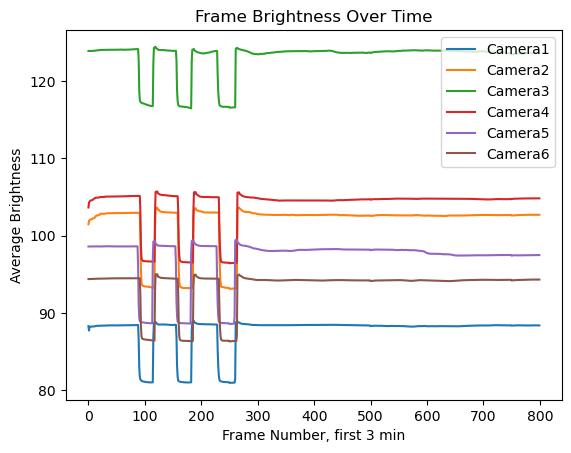

Detected intensity drop frames in /data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_16/02mouse_newobj_no_opto: {'Camera1': [90, 157, 229, 230], 'Camera2': [92, 93, 159, 160, 232, 233], 'Camera3': [90, 157, 229, 230], 'Camera4': [93, 160, 232, 233], 'Camera5': [88, 89, 155, 156, 228, 229], 'Camera6': [92, 93, 160, 232, 233]}
Processed drop frames: {'Camera1': 90, 'Camera2': 93, 'Camera3': 90, 'Camera4': 93, 'Camera5': 89, 'Camera6': 93}
89
alined data saved to: /data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_16/02mouse_newobj_no_opto/df_synced_2025_10_16_02mouse_newobj_no_opto_calib_before_label3d_dannce.mat
Alignment successful for /data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_16/02mouse_newobj_no_opto with /data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_16/02mouse_newobj_no_opto/2025_10_16_02mouse_newobj_no_opto_calib_before_label3d_dannce.mat

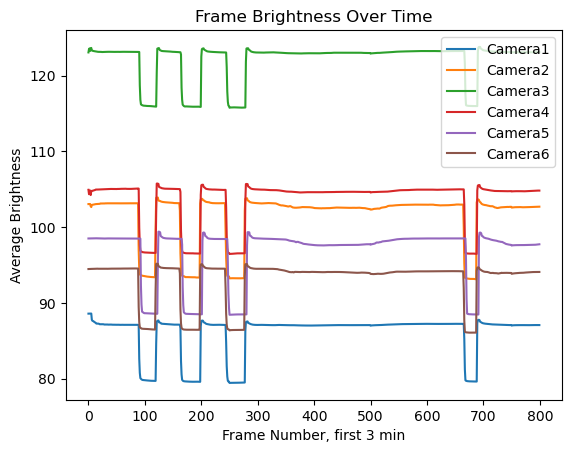

Detected intensity drop frames in /data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_16/01mouse_newobj_opto: {'Camera1': [90, 164, 244, 245, 667], 'Camera2': [89, 90, 163, 164, 243, 244, 665, 666], 'Camera3': [91, 165, 246, 668], 'Camera4': [90, 91, 164, 244, 245, 667], 'Camera5': [93, 94, 167, 168, 247, 248, 669, 670], 'Camera6': [89, 90, 163, 243, 244, 665, 666]}
Processed drop frames: {'Camera1': 90, 'Camera2': 90, 'Camera3': 91, 'Camera4': 91, 'Camera5': 94, 'Camera6': 90}
90
alined data saved to: /data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_16/01mouse_newobj_opto/df_synced_2025_10_16_01mouse_newobj_opto_calib_before_label3d_dannce.mat
Alignment successful for /data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_16/01mouse_newobj_opto with /data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_16/01mouse_newobj_opto/2025_10_16_01mouse_newobj_opto_calib

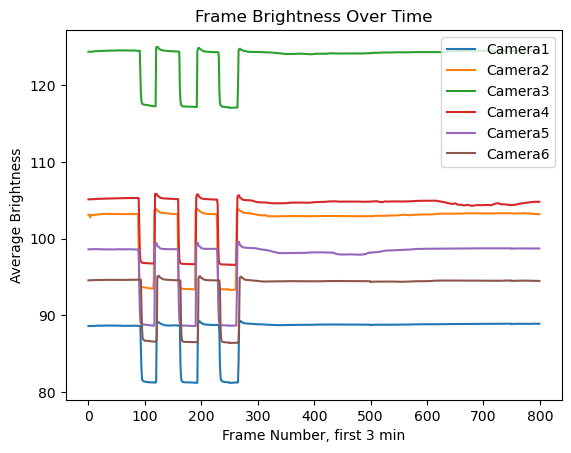

Detected intensity drop frames in /data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_16/02mouse_base03: {'Camera1': [93, 94, 163, 233], 'Camera2': [89, 90, 159, 160, 229, 230], 'Camera3': [92, 93, 162, 232], 'Camera4': [90, 91, 160, 161, 230], 'Camera5': [90, 91, 160, 161, 230, 231], 'Camera6': [94, 95, 164, 234]}
Processed drop frames: {'Camera1': 94, 'Camera2': 90, 'Camera3': 93, 'Camera4': 91, 'Camera5': 91, 'Camera6': 95}
90
alined data saved to: /data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_16/02mouse_base03/df_synced_2025_10_16_02mouse_base03_calib_before_label3d_dannce.mat
Alignment successful for /data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_16/02mouse_base03 with /data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_16/02mouse_base03/2025_10_16_02mouse_base03_calib_before_label3d_dannce.mat 
Moved prior calibration file /data/big_rim/rsync_

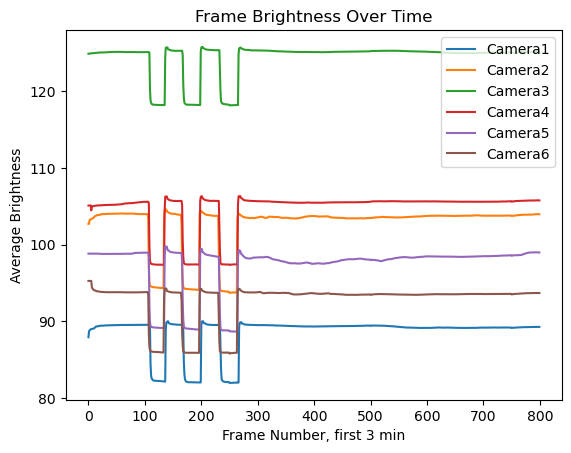

Detected intensity drop frames in /data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_16/01mouse_base03: {'Camera1': [110, 169, 234, 235], 'Camera2': [107, 108, 166, 167, 231, 232], 'Camera3': [109, 168, 233, 234], 'Camera4': [108, 167, 168, 232, 233], 'Camera5': [108, 109, 167, 168, 232, 233], 'Camera6': [107, 166, 231, 232]}
Processed drop frames: {'Camera1': 110, 'Camera2': 108, 'Camera3': 109, 'Camera4': 108, 'Camera5': 109, 'Camera6': 107}
107
alined data saved to: /data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_16/01mouse_base03/df_synced_2025_10_16_01mouse_base03_calib_before_label3d_dannce.mat
Alignment successful for /data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_16/01mouse_base03 with /data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_16/01mouse_base03/2025_10_16_01mouse_base03_calib_before_label3d_dannce.mat 
Moved prior calibration file /

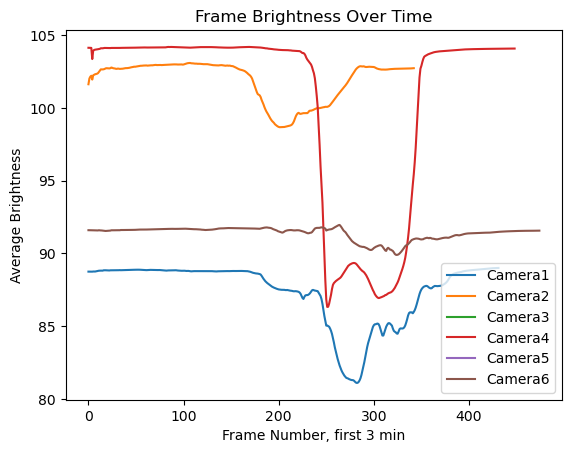

Detected intensity drop frames in /data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_14/01mouse_newobj1_non_opto: {'Camera1': [], 'Camera2': [], 'Camera3': [], 'Camera4': [], 'Camera5': [], 'Camera6': []}
Skipping process_calibration_data for /data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_14/01mouse_newobj1_non_opto due to missing drop frames
please mannually process /data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_14/01mouse_newobj1_non_opto
Failed processing: /data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_14/01mouse_newobj1_non_opto, status set to 3.
Updated Parquet file at /data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_14/01mouse_newobj1_non_opto/folder_log.parquet with new status.


In [15]:
from utlis.exe_engine_utlis.comb_all_exe import sequential_process_and_update_sync

sequential_process_and_update_sync(filtered_table, base_folder, max_frames=800) #threshold=2, max_frames=300, min_frame=0

/data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_16/02mouse_newobj_no_opto
plotting com_traga for /data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_16/02mouse_newobj_no_opto


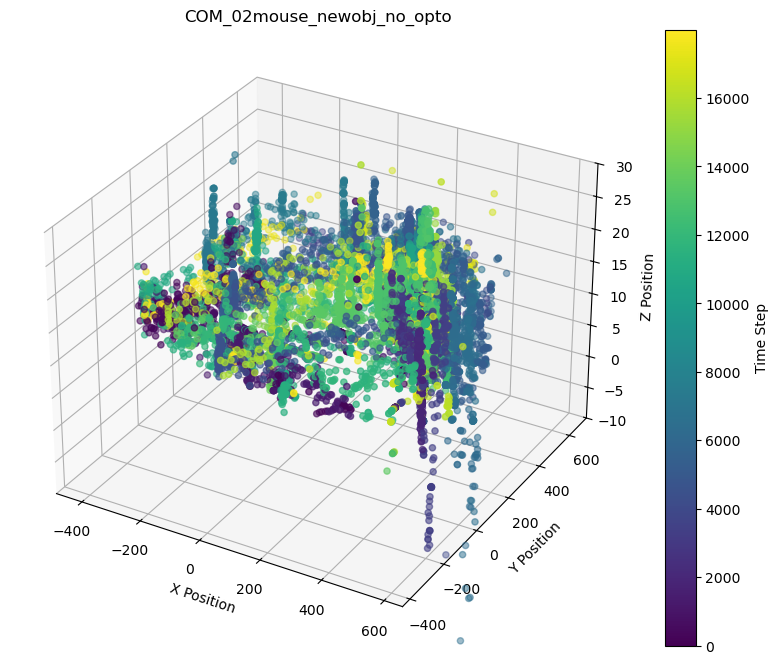

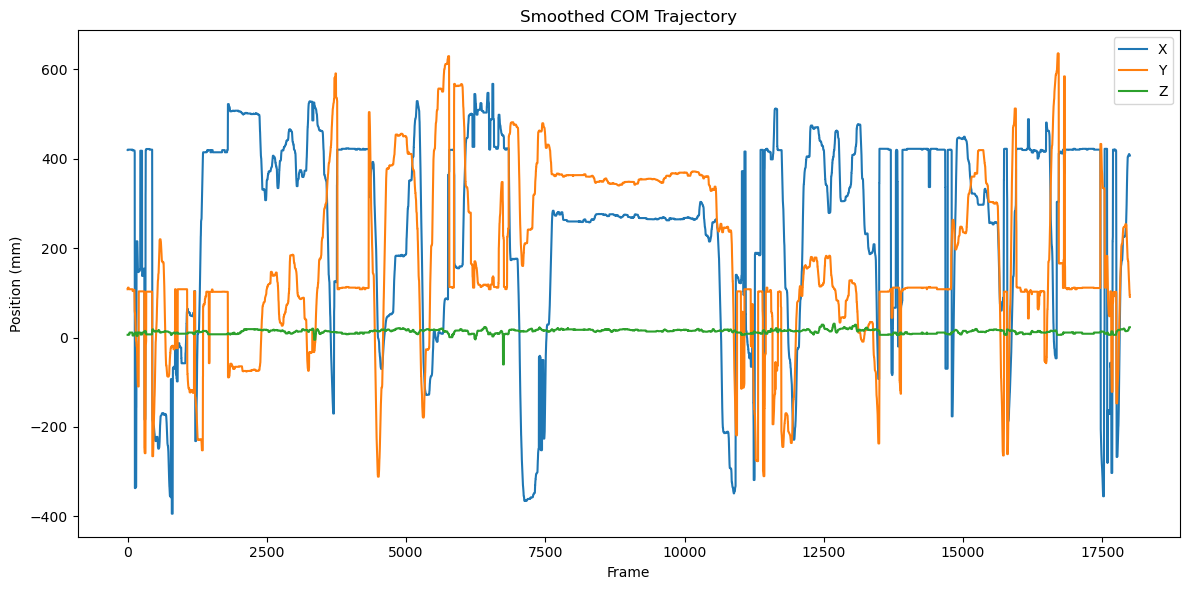

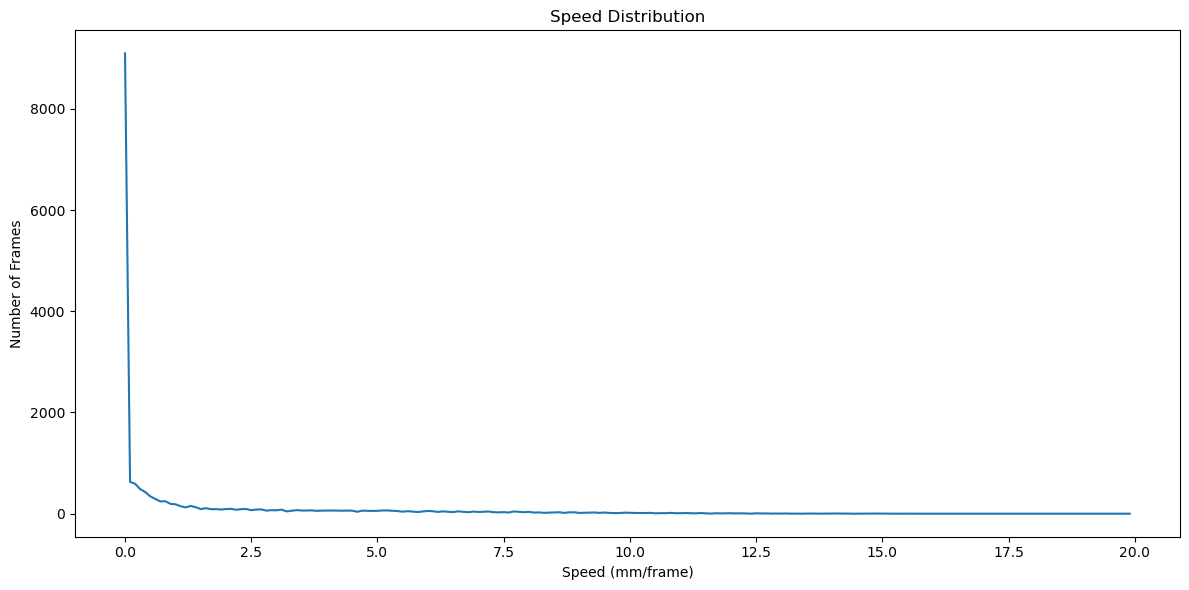

Analysis complete. Plots saved to: /data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_16/02mouse_newobj_no_opto/COM/predict00/vis
/data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_16/01mouse_newobj_opto
plotting com_traga for /data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_16/01mouse_newobj_opto


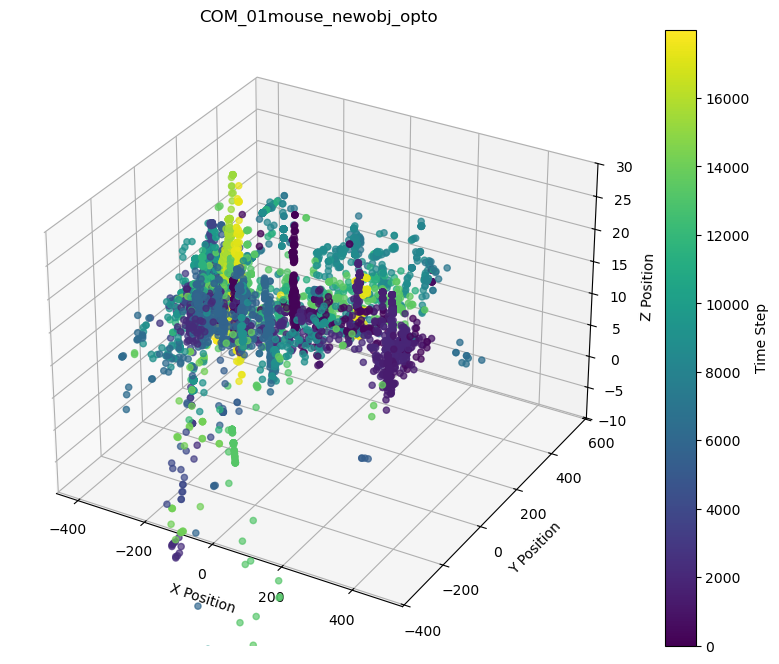

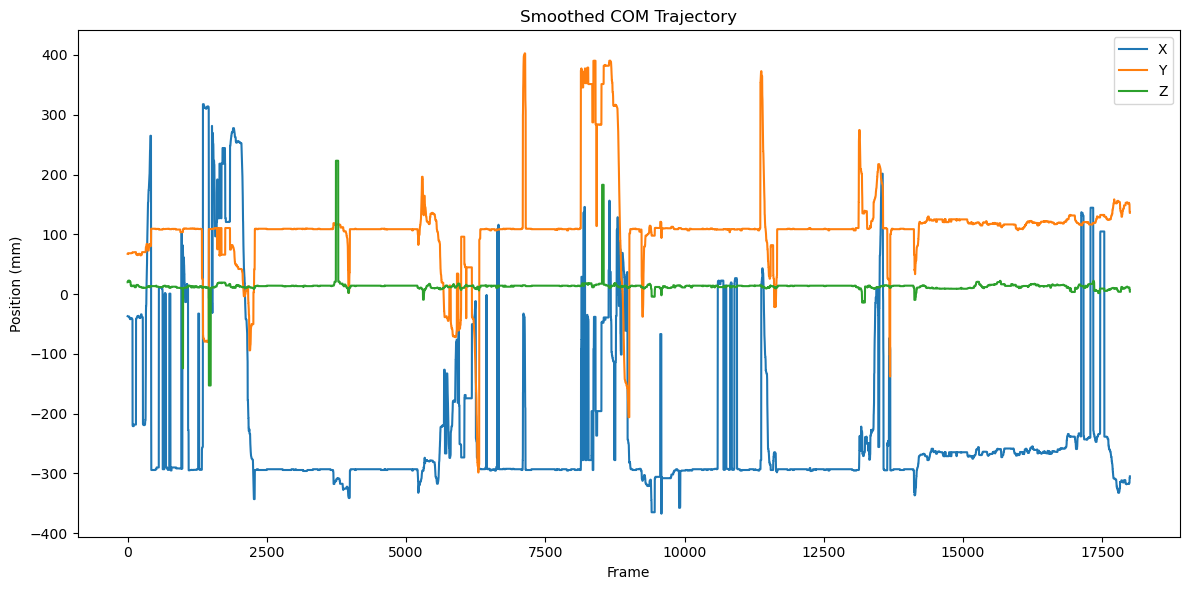

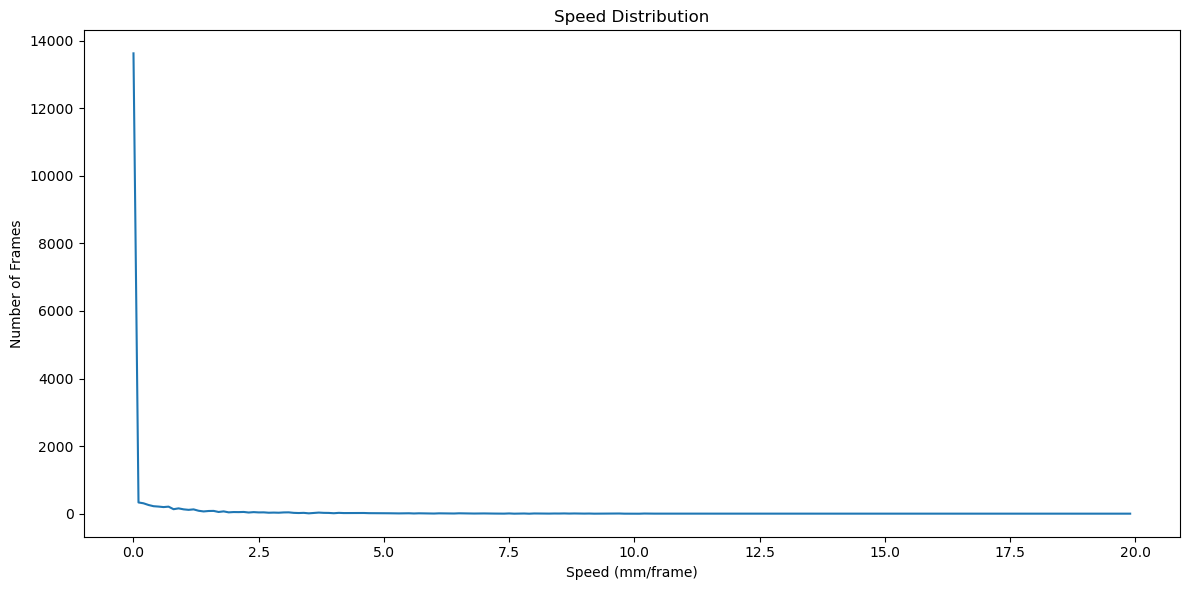

Analysis complete. Plots saved to: /data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_16/01mouse_newobj_opto/COM/predict00/vis
/data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_16/02mouse_base03
plotting com_traga for /data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_16/02mouse_base03


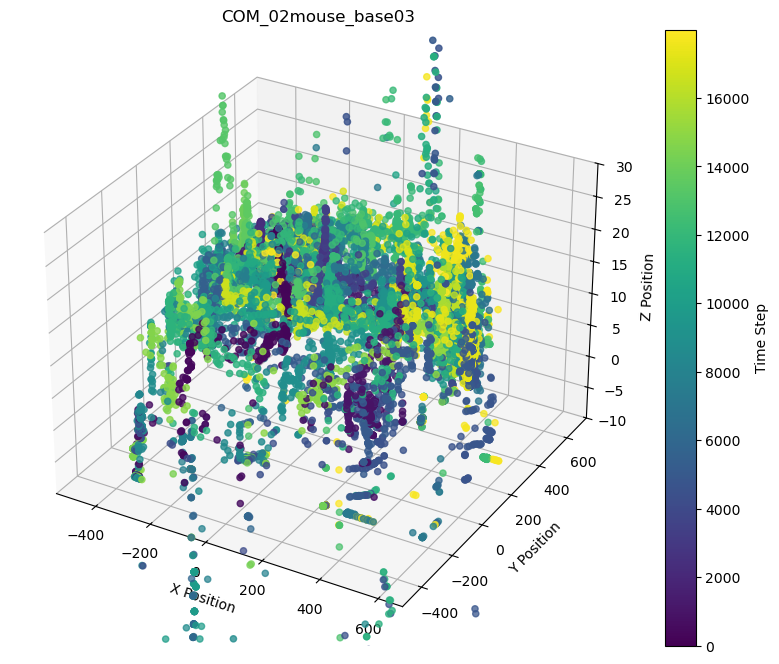

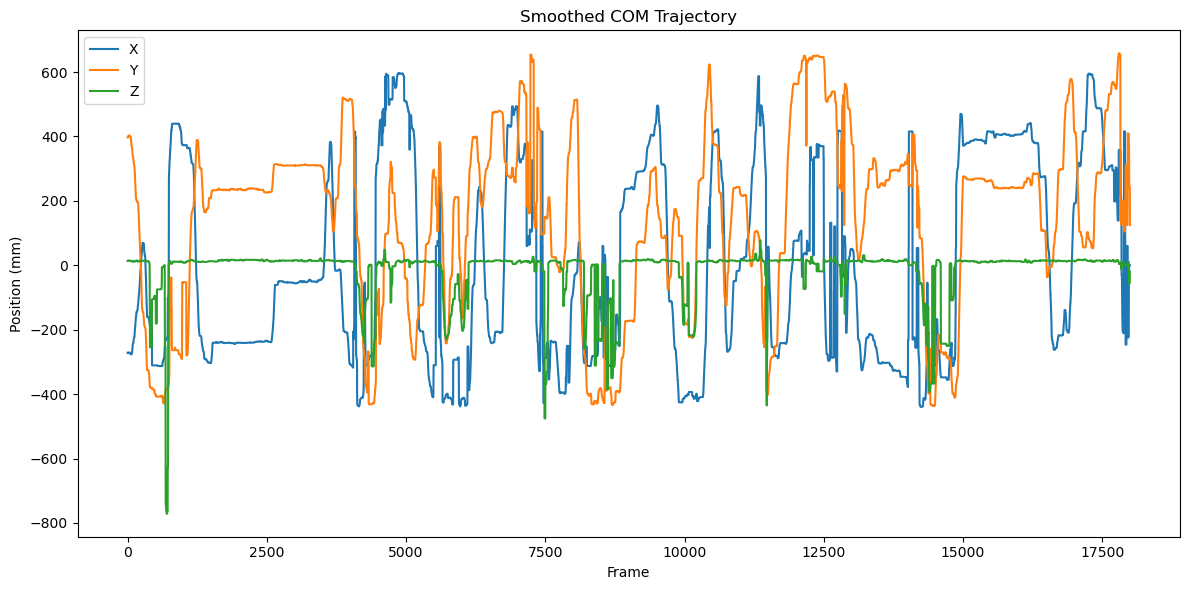

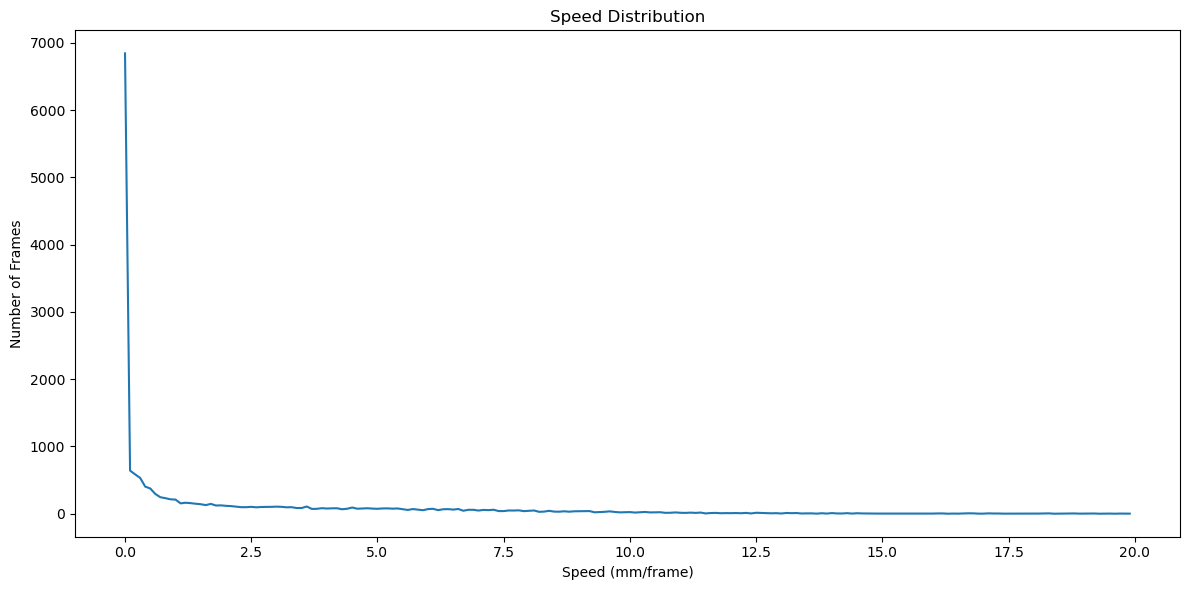

Analysis complete. Plots saved to: /data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_16/02mouse_base03/COM/predict00/vis
/data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_16/01mouse_base03
plotting com_traga for /data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_16/01mouse_base03


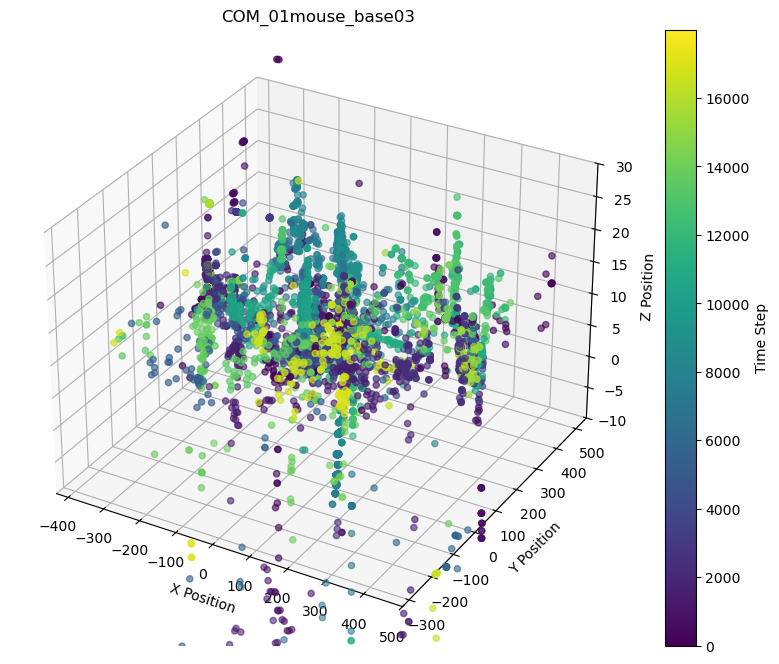

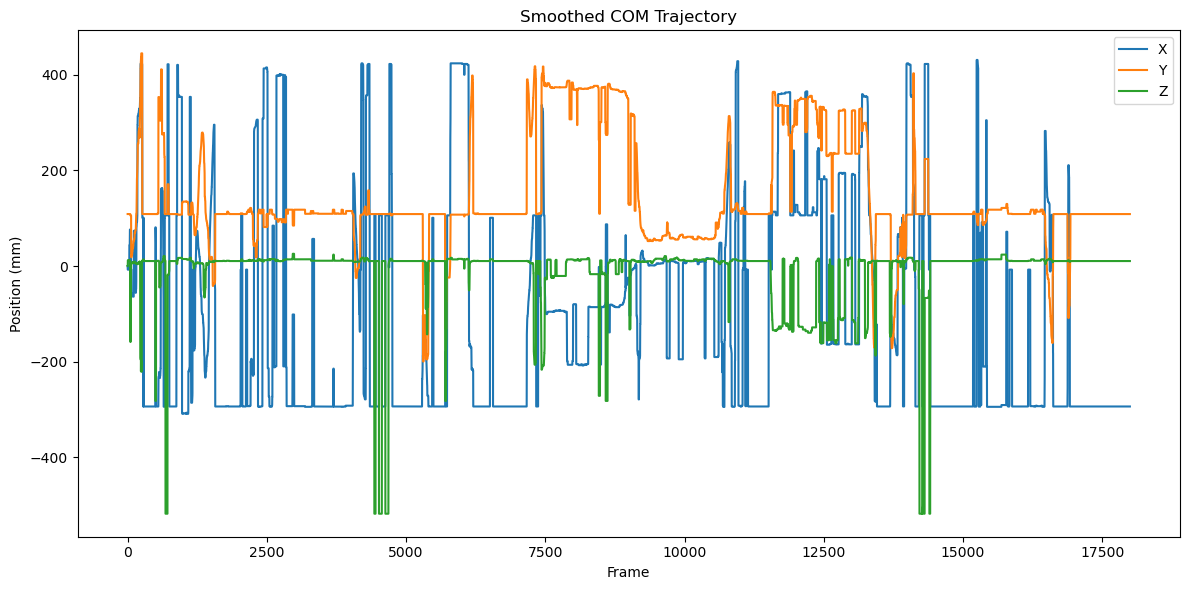

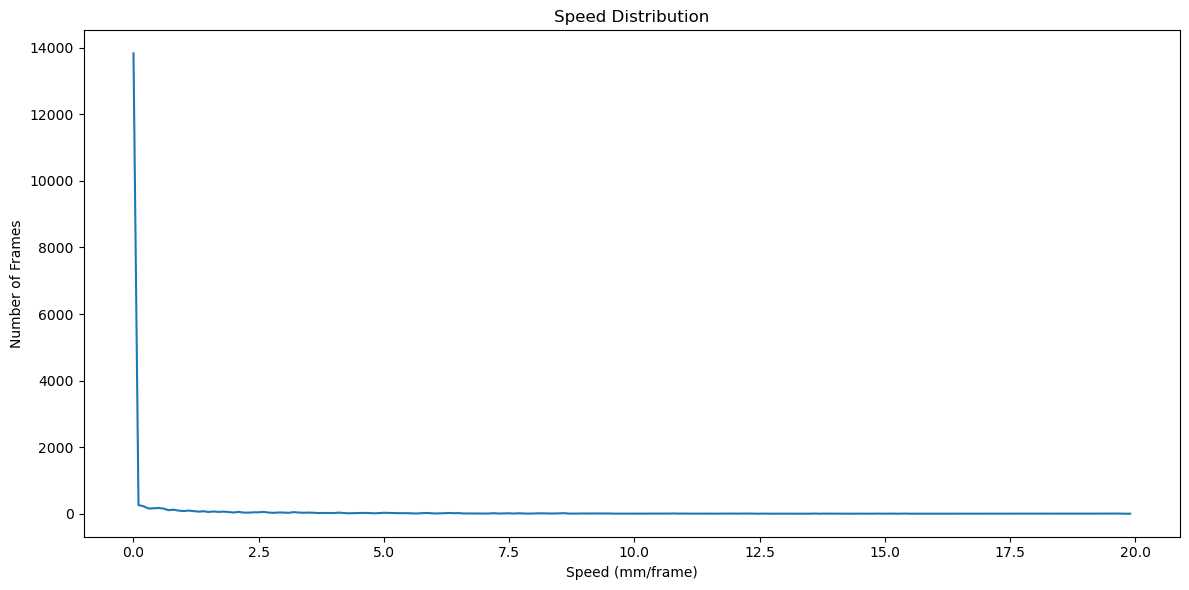

Analysis complete. Plots saved to: /data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/lumi_novel_object_recog/2025_10_16/01mouse_base03/COM/predict00/vis


In [5]:
# single com vis

from utlis.vis_valid_utlis.com_trag_updated import plot_com_all

# Assume base_folder is defined elsewhere in your script
# base_folder = '/path/to/your/base/folder'
for_com_vis = filtered_table
records = [
    {
        'date_folder': date_folder.as_py(),  # Convert to string using as_py()
        'rec_file': rec_file.as_py()         # Convert to string using as_py()
    }
    for date_folder, rec_file in zip(for_com_vis['date_folder'], for_com_vis['rec_file'])
]

# Iterate through the records and process each one sequentially
for record in records:
    base_path = f"{base_folder}/{record['date_folder']}/{record['rec_file']}"
    print(base_path)
    plot_com_all(base_path) #com_folder_name='COM/predict00', perform_jump_indices=True, perform_video_generation=False, perform_generate_com_video=False


In [ ]:
# social com vis

# from utlis.vis_valid_utlis.com_trag_updated import plot_com_all
from utlis.vis_valid_utlis.scom_traga_utlis import plot_com_all_social

# Assume base_folder is defined elsewhere in your script
# base_folder = '/path/to/your/base/folder'
for_com_vis = filtered_table
records = [
    {
        'date_folder': date_folder.as_py(),  # Convert to string using as_py()
        'rec_file': rec_file.as_py()         # Convert to string using as_py()
    }
    for date_folder, rec_file in zip(for_com_vis['date_folder'], for_com_vis['rec_file'])
]

# Iterate through the records and process each one sequentially
for record in records:
    base_path = f"{base_folder}/{record['date_folder']}/{record['rec_file']}"
    print(base_path)
    plot_com_all_social(base_path) #com_folder_name='COM/predict00', perform_jump_indices=True, perform_video_generation=False, perform_generate_com_video=False


/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_clearscup
Plot saved as '/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_clearscup/DANNCE/predict00/vis/2025_07_08_20250512PMCl23r1_clearscup.jpg'.


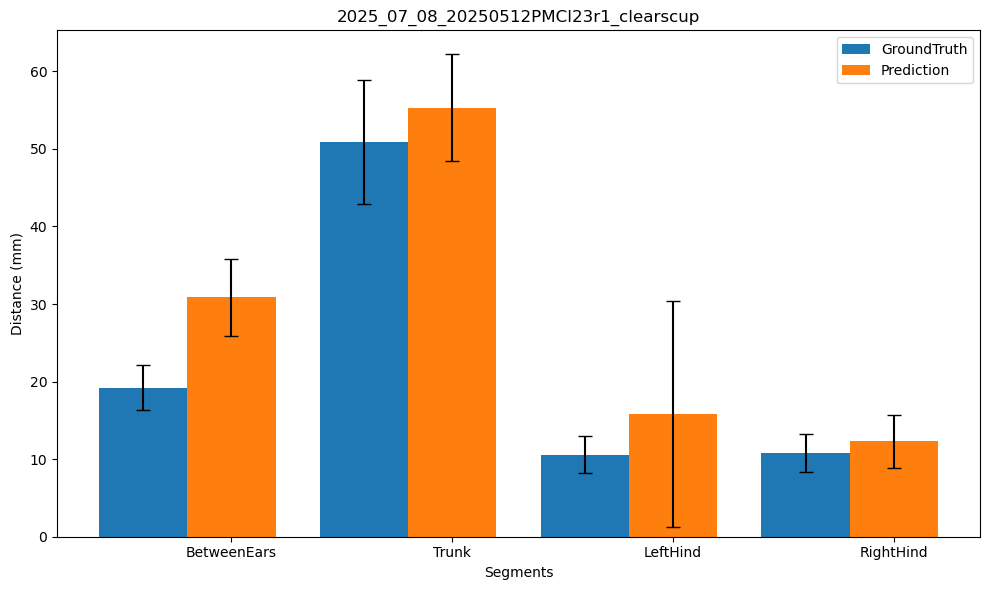

In [19]:
# single dannce valid


from useful_files.sophie_check_dannce_mir_modif import dannce_valid

for_dannce_vis = filtered_table


records = [
    {
        'date_folder': date_folder.as_py(),  # Convert to string using as_py()
        'rec_file': rec_file.as_py()         # Convert to string using as_py()
    }
    for date_folder, rec_file in zip(for_dannce_vis['date_folder'], for_dannce_vis['rec_file'])
]

# Iterate through the records and process each one sequentially
# for record in records:
#     base_path = f"{base_folder}/{record['date_folder']}/{record['rec_file']}"
#     print(base_path)
#     try:
#         dannce_valid(base_path) #com_folder_name='COM/predict00', perform_jump_indices=True, perform_video_generation=False, perform_generate_com_video=False
#     except Exception as e:
#         print(f" An error occurred while processing {base_path}: {e}")
#         # Skip to the next record if an error occurs
#         continue

# #trying for parallel processing again:
from concurrent.futures import ProcessPoolExecutor, as_completed

def process_record(record):
    base_path = f"{base_folder}/{record['date_folder']}/{record['rec_file']}"
    print(base_path)
    try:
        dannce_valid(base_path)
    except Exception as e:
        print(f"An error occurred while processing {base_path}: {e}")
        # Skip to the next record if an error occurs
        pass

with ProcessPoolExecutor() as executor:
    futures = [executor.submit(process_record, record) for record in records]
    for future in as_completed(futures):
        pass  # You can retrieve results or handle exceptions here if needed
